# SISTEMA PREDITIVO DE RESULTADOS ESPORTIVOS
O objetivo dessa atividade é integrar manipulação de dados em *SQLite* com o desenvolvimento de um modelo de classificação para prever o resultado de partidas de futebol e as chances de título de um time utilizando um modelo de Random Forest

In [16]:
# Pacotes necessários: numpy, pandas, sqlite3 e sklearn

import numpy as np
import pandas as pd
import sqlite3
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt

In [6]:
# Caminho para o arquivo da databse
database = 'database.sqlite'

conn = sqlite3.connect(database)

In [7]:
# Criando DataFrames a partir das tabelas
matches_df = pd.read_sql("""SELECT * from MATCH""", conn) # Partidas
teams_df = pd.read_sql("""SELECT * from TEAM""", conn) # Times
player_attributes_df = pd.read_sql("""SELECT * from PLAYER_ATTRIBUTES""", conn) # Atributos dos Jogadores

display(matches_df.head())
display(teams_df.head())
display(player_attributes_df.head())

# Ordenar por data
matches_df['date'] = pd.to_datetime(matches_df['date'], format='%Y-%m-%d 00:00:00')
matches_df.sort_values(by=['date'], inplace=True)

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673.0,KRC Genk,GEN
1,2,9993,675.0,Beerschot AC,BAC
2,3,10000,15005.0,SV Zulte-Waregem,ZUL
3,4,9994,2007.0,Sporting Lokeren,LOK
4,5,9984,1750.0,KSV Cercle Brugge,CEB


,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


# Extração dos dados


In [8]:
home_players = ["home_player_" + str(x) for x in range(1, 12)]
away_players = ["away_player_" + str(x) for x in range(1, 12)]

matches_kept_columns = ["id", "date", "home_team_api_id", "away_team_api_id", "home_team_goal", "away_team_goal"]
matches_kept_columns = matches_kept_columns + home_players
matches_kept_columns = matches_kept_columns + away_players

matches_df = matches_df[matches_kept_columns]

for player in home_players:
    matches_df = pd.merge(matches_df, player_attributes_df[["id", "overall_rating"]], left_on=[player], right_on=["id"], suffixes=["", "_" + player], how='left')
for player in away_players:
    matches_df = pd.merge(matches_df, player_attributes_df[["id", "overall_rating"]], left_on=[player], right_on=["id"], suffixes=["", "_" + player], how='left')

matches_df = matches_df.rename(columns={"overall_rating": "overall_rating_home_player_1"})

# Tratar ratings nulos com SimpleImputer
rating_cols = [col for col in matches_df.columns if col.startswith('overall_rating_')]

imputer = SimpleImputer(strategy='median')  # Substituir os valores nulos pela mediana do overall

matches_df[rating_cols] = imputer.fit_transform(matches_df[rating_cols])

# Média do rating dos times
matches_df['mean_overall_rating_home'] = matches_df[['overall_rating_' + p for p in home_players]].mean(axis=1).round(2)
matches_df['mean_overall_rating_away'] = matches_df[['overall_rating_' + p for p in away_players]].mean(axis=1).round(2)

for c in matches_df.columns:
    if '_player_' in c:
        matches_df = matches_df.drop(c, axis=1)

# matches_df.dropna(subset=['mean_overall_rating_home', 'mean_overall_rating_away'], inplace=True)

display(matches_df.head())

,id,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,mean_overall_rating_home,mean_overall_rating_away
0,24559,2008-07-18,10192,9931,1,2,68.91,68.91
1,24560,2008-07-19,9930,10179,3,1,68.91,68.91
2,24561,2008-07-20,10199,9824,1,2,68.91,68.91
3,24562,2008-07-20,7955,10243,1,2,68.91,68.91
4,24614,2008-07-23,6493,7955,1,2,68.91,68.91


In [9]:
# Diferença de gols no histórico dos confrontos

def get_h2h(date, home_team, away_team, df_all):

    historico = df_all[
        (df_all['date'] < date) &
        (df_all['home_team_api_id'] == home_team) &
        (df_all['away_team_api_id'] == away_team)
    ]

    if historico.empty:
        return 0.0

    diff = (historico['home_team_goal'] - historico['away_team_goal']).sum()
    return round(diff, 3)

matches_df['h2h_goal_diff'] = matches_df.apply(
    lambda row: get_h2h(
        row['date'],
        row['home_team_api_id'],
        row['away_team_api_id'],
        matches_df
    ),
    axis=1
)

display(matches_df.head())


,id,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,mean_overall_rating_home,mean_overall_rating_away,h2h_goal_diff
0,24559,2008-07-18,10192,9931,1,2,68.91,68.91,0.0
1,24560,2008-07-19,9930,10179,3,1,68.91,68.91,0.0
2,24561,2008-07-20,10199,9824,1,2,68.91,68.91,0.0
3,24562,2008-07-20,7955,10243,1,2,68.91,68.91,0.0
4,24614,2008-07-23,6493,7955,1,2,68.91,68.91,0.0


# Resultados das partidas
Vamos adicionar uma coluna contendo os resultados de cada jogo:
* (0) **Vitória do time da casa**
* (1) **Empate**
* (2) **Vitória do time visitante**


In [10]:
def match_result(home_goals, away_goals):
    if home_goals > away_goals:
        return 0
    elif home_goals < away_goals:
        return 2
    else:
        return 1

matches_df['result'] = matches_df.apply(
    lambda row: match_result(
        row['home_team_goal'],
        row['away_team_goal']
    ),
    axis=1
)

display(matches_df.tail())

,id,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,mean_overall_rating_home,mean_overall_rating_away,h2h_goal_diff,result
25974,25945,2016-05-25,9931,9956,0,1,68.18,69.45,14.0,2
25975,25946,2016-05-25,7896,10190,3,0,68.64,64.36,2.0,0
25976,25947,2016-05-25,10199,10179,2,2,66.27,69.09,2.0,1
25977,25948,2016-05-25,10191,10192,0,3,73.45,69.36,-3.0,2
25978,25949,2016-05-25,10243,9824,3,1,71.82,69.27,9.0,0


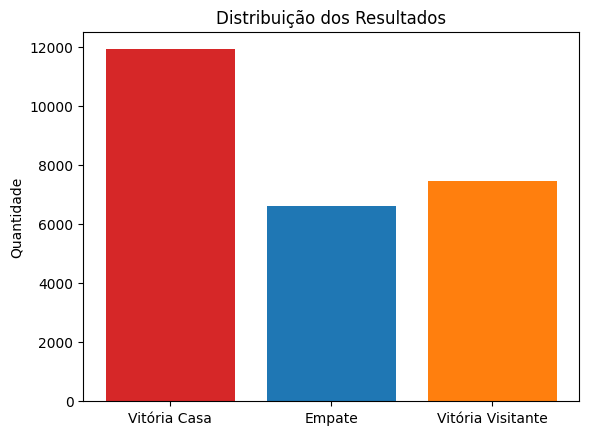

In [11]:
# Distribuição dos resultados das partidas

fig, ax = plt.subplots()

results = ['Vitória Casa', 'Empate', 'Vitória Visitante']
counts = [len(matches_df[matches_df['result'] == 0]), len(matches_df[matches_df['result'] == 1]), len(matches_df[matches_df['result'] == 2])]
bar_labels = ['red', 'blue', 'orange']
bar_colors = ['tab:red', 'tab:blue', 'tab:orange']

ax.bar(results, counts, label=bar_labels, color=bar_colors)

ax.set_ylabel('Quantidade')
ax.set_title('Distribuição dos Resultados')

plt.show()

# Treinamento do modelo com RandomForest
## Features usadas:
* ID dos times
* Média do Overall dos jogadores titulares
* Diferença de gols histórica

In [13]:
features = ['home_team_api_id', 'away_team_api_id', 'mean_overall_rating_home', 'mean_overall_rating_away', 'h2h_goal_diff']
target = 'result'

X = matches_df[features]
y = matches_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Escalonamento de variáveis numéricas e tratamento dos IDs

scaler = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), ['mean_overall_rating_home', 'mean_overall_rating_away', 'h2h_goal_diff']),
    ('encoder', OneHotEncoder(), ['home_team_api_id', 'away_team_api_id'])
], remainder='passthrough')

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Classificador com Random Forest

modelo = RandomForestClassifier(n_estimators=100,
                                class_weight='balanced',
                                random_state=42,
                                n_jobs=-1)
modelo.fit(X_train,y_train)

# Cross Validation com K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_acc = cross_val_score(modelo, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
scores_f1 = cross_val_score(modelo, X_train, y_train, cv=kf, scoring='f1_macro', n_jobs=-1)

print(f"== Cross Validation Scores ==")
print(f"Acurácia: {scores_acc.mean():.3f} +/- {scores_acc.std():.3f}")
print(f"F1:       {scores_f1.mean():.3f} +/- {scores_f1.std():.3f}")

== Cross Validation Scores ==
Acurácia: 0.473 +/- 0.003
F1:       0.399 +/- 0.003


In [15]:
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.72      0.61      2384
           1       0.28      0.16      0.21      1319
           2       0.44      0.32      0.37      1493

    accuracy                           0.47      5196
   macro avg       0.41      0.40      0.39      5196
weighted avg       0.44      0.47      0.44      5196



# Simulação de Campeonato com Monte Carlo
Vamos utilizar o modelo treinado com RandomForest para calcular a probabilidade de um certo time ser campeão de algum dos campeonatos contidos na base de dados

In [14]:
# 1729 England Premier League
# 4769 France Ligue 1
# 7809 Germany 1. Bundesliga
# 10257 Italy Serie A
# 13274 Netherlands Eredivisie
# 15722 Poland Ekstraklasa
# 17642 Portugal Liga ZON Sagres
# 19694 Scotland Premier League
# 21518 Spain LIGA BBVA
# 24558 Switzerland Super League


league_id = 1729
season = '2015/2016'

query_simulation = f"SELECT id, date, home_team_api_id, away_team_api_id, home_team_goal, away_team_goal FROM MATCH WHERE league_id = {league_id} AND season = '{season}'"
matches_to_simulate = pd.read_sql(query_simulation, conn)
matches_to_simulate['date'] = pd.to_datetime(matches_to_simulate['date'])

simulation_df = pd.merge(matches_to_simulate, matches_df[['id', 'mean_overall_rating_home', 'mean_overall_rating_away', 'h2h_goal_diff']], on='id')

X_sim = scaler.transform(simulation_df[features])
probs = modelo.predict_proba(X_sim)

print(probs)

team_names = teams_df.set_index('team_api_id')['team_long_name'].to_dict()

n_simulations = 1000
champions_count = {}

# 1000 simulações

for _ in range(n_simulations):
    points = {team: 0 for team in pd.concat([simulation_df['home_team_api_id'], simulation_df['away_team_api_id']]).unique()}

    for i in range(len(simulation_df)):
        res = np.random.choice([0, 1, 2], p=probs[i])

        home_team = simulation_df.iloc[i]['home_team_api_id']
        away_team = simulation_df.iloc[i]['away_team_api_id']

        if res == 0:
            points[home_team] += 3
        elif res == 2:
            points[away_team] += 3
        else:
            points[home_team] += 1
            points[away_team] += 1

    winner = max(points, key=points.get)
    champions_count[winner] = champions_count.get(winner, 0) + 1

print("🏆 Ranking de probabilidade de título (Premier League 2015/2016):")
results_df = pd.DataFrame([
    {'Time': team_names.get(tid, tid),
     'Títulos': count,
     'Probabilidade (%)': (count / n_simulations) * 100}
    for tid, count in champions_count.items()
]).sort_values(by='Probabilidade (%)', ascending=False)

display(results_df)

[[0.32 0.05 0.63]
 [0.18 0.2  0.62]
 [0.24 0.73 0.03]
 ...
 [0.29 0.68 0.03]
 [0.25 0.17 0.58]
 [0.43 0.4  0.17]]
🏆 Ranking de probabilidade de título (Premier League 2015/2016):


,Time,Títulos,Probabilidade (%)
3,Arsenal,419,41.9
1,Tottenham Hotspur,303,30.3
0,Manchester City,123,12.3
4,Leicester City,75,7.5
2,Manchester United,63,6.3
5,Chelsea,12,1.2
6,Southampton,3,0.3
7,Liverpool,2,0.2
